<a href="https://colab.research.google.com/github/lelax/LinkedTaiwanArtists/blob/main/TAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAIWHY-ART

This Jupyter Notebook was created for the exam Information Visualization taught by professor Marilena Daquino at the University of Bologna for the year 2022/2023. The team project is composed by DHDK's students Marida, Van and Carmela.

**About**

The project explores biographical resources and historical data from Linked Taiwanese Artists dataset regarding Taiwanese artists who crafted their works during the Japanese colonial period, spanning from 1895 to 1945.

# Step 1: Querying the ontology

We downloaded the OWL file of the dataset at this [link](https://linkedart.ascdc.tw/about.php). Then we manually changed some date format issues regarding the birth and death date in order to make them compliant to the 8601 ISO format.

After this brief data cleaning process, we imported Python's rdflib library to load our OWL file and then query the ontology.
In this way an RDF graph is created, our OWL file called ASCDC_Taiwan Artists.owl is loaded in XML format and a namaspace is defined to shorten references to resources contained in the ontology.



Therefore, we made a series of SPARQL queries to extract informations related to the artists and what they did during their artistic production.

In [ ]:
!pip install rdflib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.9/564.9 kB 6.8 MB/s eta 0:00:00


## WHO
**1. Who are the most influential Taiwanese artists during the Japanese colonial period (1895-1945)?**

First, we asked ourselves who the most productive Taiwanese artists were during the Japanese colonial period according to the data in our database.

Therefore, this script uses **rdflib** to analyze an RDF/OWL file containing data on Taiwanese artists. It runs a SPARQL query to find the top 5 authors with the most paintings, sorting them in descending order. The results are printed on the screen and saved in a CSV file (**top_5_authors_paintings.csv**).

In [ ]:
from rdflib import Graph, Namespace
import logging
import csv

# Suppress RDFlib warnings
logging.getLogger("rdflib.term").setLevel(logging.ERROR)

# Load the RDF data
g = Graph()
g.parse("ASCDC_Taiwan Artists.owl", format="xml")  # Replace with the actual filename

# Define the namespace
RDFS = Namespace("http://www.w3.org/2000/01/rdf-schema#")
SCHEMA = Namespace("http://schema.org/")

# Query to retrieve the top 5 authors with the most paintings
query = """
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX schema: <http://schema.org/>
SELECT ?authorName (COUNT(?painting) AS ?paintingCount)
WHERE {
    ?painting a <http://linkedart.ascdc.tw/lod/ontology#Painting> .
    ?painting schema:creator ?author .
    ?author rdfs:label ?authorName .
    FILTER (LANG(?authorName) = "en")
}
GROUP BY ?authorName
ORDER BY DESC(?paintingCount)
LIMIT 5
"""

# Execute the query
try:
    results = g.query(query)
    data = []

    # Collect results
    for row in results:
        data.append([row.authorName, row.paintingCount])
        print(f"Author: {row.authorName}, Paintings: {row.paintingCount}")

    # Save results to CSV
    csv_filename = "top_5_authors_paintings.csv"
    with open(csv_filename, mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(["Author", "Number of Paintings"])
        writer.writerows(data)

    print(f"Top 5 authors with the most paintings saved to {csv_filename}")
except Exception as e:
    print(f"Error executing query: {e}")

Author: Chen Cheng-po, Paintings: 157
Author: Yang San-lang, Paintings: 35
Author: Liao Chi-chun, Paintings: 27
Author: Li Shih-chiao, Paintings: 25
Author: Chen Jin, Paintings: 23
Top 5 authors with the most paintings saved to top_5_authors_paintings.csv


The query shows **Chen Cheng-po** as the most prolific artist, with 157 paintings, followed by **Yang San-lang** with 35, **Liao Chi-chun** with 27, Li Shih-chiao with 25, and Chen Jin with 23. These results highlight the significant contribution of Chen Cheng-po, a key figure in Taiwanese art during the period in question.

**2. Top 10 organizations responsible for the most exhibitions over the years**

By examining our ontology using the Protégé software, we identified the presence of the class *Organization* and therefore investigated it.
First, we asked a basic question: which were the most active organizations that had organized the most art exhibitions?
Thus, the query displays the top 10 organizations with the most exhibitions.

In [ ]:
from rdflib import Graph, Namespace
from collections import defaultdict

SCHEMA = Namespace("http://schema.org/")
RDFS = Namespace("http://www.w3.org/2000/01/rdf-schema#")

# Dictionary to count exhibitions per organization
organization_count = defaultdict(int)

# Iterate through each exhibition in the graph
for s in g.subjects(predicate=RDFS.label):
    organization = g.value(s, SCHEMA.organizer)
    if organization:
        # Retrieve all labels for the organization
        labels = g.objects(organization, RDFS.label)
        organization_label = None

        # Find the English label if available
        for label in labels:
            if label.language == "en":
                organization_label = str(label)
                break

        # If no English label, use the first available label
        if not organization_label and labels:
            organization_label = str(next(iter(labels)))

        if organization_label:
            organization_count[organization_label] += 1

# Sort the organizations by the number of exhibitions and get the top 10
top_organizations = sorted(organization_count.items(), key=lambda x: x[1], reverse=True)[:10]

# Print the top 10 organizations responsible for the most exhibitions
print("Top 10 organizations responsible for the most exhibitions:")
for organization, count in top_organizations:
    print(f"Organization: {organization}, Number of Exhibitions: {count}")


Top 10 organizations responsible for the most exhibitions:
Organization: Japanese Ministry of Education, Science and Culture, Number of Exhibitions: 38
Organization: Tai-Yang Art Society, Number of Exhibitions: 20
Organization: Taiwan Education Association, Number of Exhibitions: 20
Organization: Kofukai Art Association, Number of Exhibitions: 18
Organization: Imperial Fine Arts Academy, Number of Exhibitions: 14
Organization: Syunyo-kai Art Society, Number of Exhibitions: 12
Organization: Taiwan Governor-General's Office, Number of Exhibitions: 10
Organization: Hakujitsukai, Number of Exhibitions: 8
Organization: Kaijusha, Number of Exhibitions: 8
Organization: Hongo Painting Institute, Number of Exhibitions: 4


The results show that the **Japanese Ministry of Education, Science and Culture** organized the most exhibitions, with 38 events. Other key organizations include the **Tai-Yang Art Society** and the **Taiwan Education Association**, each with 20 exhibitions. The **Kofukai Art Association and Imperial Fine Arts Academy** follow with 18 and 14 exhibitions, respectively. Several other organizations like the **Syunyo-kai Art Society** and **Taiwan Governor-General's Office** also contributed significantly, with 10 or more exhibitions. These results highlight the key role of government and cultural institutions in organizing exhibitions during the period.

## WHAT

**1. What exhibition had more editions in Taiwan compared to the international exhibitions?**

So, we then asked ourselves which exhibitions were held more frequently in Taiwan compared to international ones, in order to examine whether our dataset also considered exhibitions held abroad.

By grouping the data by exhibition type, we can identify which exhibitions had a stronger presence in Taiwan and which had more editions abroad. The results offer insights into the geographic distribution of artistic events and help understanding the prominence of Taiwan-based exhibitions in the broader art scene.


In [ ]:
#query to discover which exhibitions had more editions in Taiwan compared to the international ones
query = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX schema: <http://schema.org/>
PREFIX ex: <http://linkedart.ascdc.tw/lod/ontology#>

SELECT ?exhibitionType (COUNT(?taiwanEdition) AS ?taiwanCount) (COUNT(?intlEdition) AS ?intlCount)
WHERE {
  ?edition rdf:type ?exhibitionType .
  ?exhibitionType rdfs:subClassOf ex:Exhibition .

  OPTIONAL {
    ?edition schema:location ?location .
    ?location rdf:type ex:Taiwan .
    BIND(?edition AS ?taiwanEdition)
  }

  OPTIONAL {
    ?edition schema:location ?location .
    FILTER NOT EXISTS {?location rdf:type ex:Taiwan}
    BIND(?edition AS ?intlEdition)
  }
}
GROUP BY ?exhibitionType
ORDER BY DESC(?taiwanCount) DESC(?intlCount)
"""

results = g.query(query)

for row in results:
    print(f"Exhibition Type: {row.exhibitionType}")
    print(f"Editions in Taiwan: {row.taiwanCount}")
    print(f"International Editions: {row.intlCount}")
    print("-" * 40)

Exhibition Type: http://linkedart.ascdc.tw/lod/ontology#TaiwanProvincialArtExhibition
Editions in Taiwan: 29
International Editions: 0
----------------------------------------
Exhibition Type: http://linkedart.ascdc.tw/lod/ontology#OtherExhibition
Editions in Taiwan: 8
International Editions: 14
----------------------------------------
Exhibition Type: http://linkedart.ascdc.tw/lod/ontology#JapanMinistryofEducationArtExhibition
Editions in Taiwan: 0
International Editions: 18
----------------------------------------
Exhibition Type: http://linkedart.ascdc.tw/lod/ontology#TaiwanArtExhibition
Editions in Taiwan: 0
International Editions: 12
----------------------------------------
Exhibition Type: http://linkedart.ascdc.tw/lod/ontology#Tai-YangArtExhibition
Editions in Taiwan: 0
International Editions: 10
----------------------------------------
Exhibition Type: http://linkedart.ascdc.tw/lod/ontology#KofukaiExhibition
Editions in Taiwan: 0
International Editions: 9
----------------------

The *Taiwan Provincial Art Exhibitio*n stands out as the most prominent local event, with 29 editions exclusively in Taiwan. In contrast, several exhibitions, such as the *Japan Ministry of Education Art Exhibition* (18 editions) and the *Taiwan Art Exhibition* (12 editions), have been held exclusively outside Taiwan.

Notably, several major exhibitions, such as *Tai-Yang Art Exhibition*, *Imperial Art Exhibition*, and *Syunyokai Art Exhibition*, were held only abroad, reinforcing the international scope of certain artistic movements.

Overall, this analysis highlights the strong local presence of some exhibitions while showcasing the global reach of others, providing valuable insights into the historical and geographical distribution of artistic events.

**2. What subjects are depicted in the works of Taiwanese artists?**

Right after, we asked ourselves which themes and subjects of the paintings exhibited in these shows we could extract from our dataset, so we ran a query that retrieves paintings along with their titles, authors, subjects, and exhibitions, filtering out titles containing "Postcard" or starting with "Letter from" which are two other types of entities present. The results are processed to merge duplicates and are printed on the screen. Finally, the data is saved in a CSV file (paintings_info.csv).

In [ ]:
from rdflib import Graph, Namespace
import logging
import csv

# Suppress RDFlib warnings
logging.getLogger("rdflib.term").setLevel(logging.ERROR)

# Load the RDF data
g = Graph()
g.parse("ASCDC_Taiwan Artists.owl", format="xml")  # Replace with the actual filename

# Define the namespaces
CRM = Namespace("http://purl.org/NET/cidoc-crm/core#")  # Verified CRM namespace
RDFS = Namespace("http://www.w3.org/2000/01/rdf-schema#")
SCHEMA = Namespace("http://schema.org/")

# Query to retrieve paintings with subjects, authors, titles, and exhibitions in English
query = """
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX schema: <http://schema.org/>
PREFIX crm: <http://purl.org/NET/cidoc-crm/core#>

SELECT DISTINCT ?painting ?title ?creatorName ?subjectName ?exhibitionLabel
WHERE {
    ?painting a ?paintingClass .
    ?painting rdfs:label ?title .
    ?painting schema:creator ?creator .
    ?creator rdfs:label ?creatorName .
    FILTER (LANG(?title) = "en")
    FILTER (LANG(?creatorName) = "en")

    # Exclude any painting that contains "Postcard" in the title
    FILTER (!CONTAINS(LCASE(?title), "postcard"))

    # Exclude any painting whose title starts with "Letter from"
    FILTER (!STRSTARTS(LCASE(?title), "letter from"))

    OPTIONAL {
        ?painting crm:P62_depicts ?subject .
        ?subject rdfs:label ?subjectName .
        FILTER (LANG(?subjectName) = "en")
    }

    OPTIONAL {
        ?painting crm:P12_was_present_at ?exhibition .
        ?exhibition rdfs:label ?exhibitionLabel .
        FILTER (LANG(?exhibitionLabel) = "en")
    }
}
"""

# Execute the query
try:
    results = g.query(query)
    paintings_data = {}

    # Collect results
    for row in results:
        painting_uri = str(row.painting) if row.painting else "N/A"
        title = str(row.title) if row.title else "N/A"
        creator = str(row.creatorName) if row.creatorName else "N/A"
        subject = str(row.subjectName) if row.subjectName else "None"
        exhibition = str(row.exhibitionLabel) if row.exhibitionLabel else "None"

        # Use the painting URI as the unique key to merge duplicates
        if painting_uri not in paintings_data:
            paintings_data[painting_uri] = {
                "title": title,
                "creator": creator,
                "subjects": set(),
                "exhibitions": set()
            }

        paintings_data[painting_uri]["subjects"].add(subject)
        paintings_data[painting_uri]["exhibitions"].add(exhibition)

    # Convert dictionary back to a sorted list
    sorted_paintings = sorted(
        [
            (uri, data["title"], data["creator"], ", ".join(sorted(data["subjects"])), ", ".join(sorted(data["exhibitions"])))
            for uri, data in paintings_data.items()
        ],
        key=lambda x: x[0]
    )

    # Print results
    for painting in sorted_paintings:
        print(f"Painting: {painting[1]}, Author: {painting[2]}, Subjects: {painting[3]}, Exhibitions: {painting[4]}")

    # Save results to CSV
    csv_filename = "paintings_info.csv"
    with open(csv_filename, mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(["Painting URI", "Title", "Author", "Subjects", "Exhibitions"])
        writer.writerows(sorted_paintings)

    print(f"Results saved to {csv_filename}")
except Exception as e:
    print(f"Error executing query: {e}")

Painting: A Beautiful Day, Author: Li Mei-shu, Subjects: None, Exhibitions: Taiwan Viceroy Art Exhibition_5th
Painting: A Distant View of Ancient City, Author: Yang San-lang, Subjects: None, Exhibitions: Syunyokai Art Exhibition_12th
Painting: A Distant View of Guanyin Mountain, Author: Chen Cheng-po, Subjects: None, Exhibitions: Tai-Yang Art Exhibition_2nd
Painting: A Distant View of the Monopoly Bureau, Author: Chen Cheng-po, Subjects: big chimney, farm, industrial landscapes, spire, staffage, Exhibitions: None
Painting: A Seated Figure, Author: Li Shih-chiao, Subjects: None, Exhibitions: Taiwan Viceroy Art Exhibition_6th
Painting: Abbey of Santa Lucia, Author: Yang San-lang, Subjects: None, Exhibitions: Syunyokai Art Exhibition_12th
Painting: Accordion, Author: Chen Jin, Subjects: None, Exhibitions: Taiwan Art Exhibition_9th
Painting: African Woman, Author: Pan Yu-liang, Subjects: None, Exhibitions: National Fine Art Exhibition_1st
Painting: After Singing, Author: Pan Yu-liang, Subj

These data provide detailed information about the artworks, artists, and their participation in various exhibitions, helping to create a network of connections in the artistic context.
All of this information will be further investigated in the third step of the data visualization.

**3. Which paintings have the theme of female portrait, who created them, and in which exhibition were they presented?**

Regarding the theme of the paintings, in the first step, we decided to investigate the theme of female portraits.

In [ ]:
from rdflib import Graph, Namespace
import csv
import logging

# Suppress RDFlib warnings
logging.getLogger("rdflib.term").setLevel(logging.ERROR)

# Load the RDF data
g = Graph()
g.parse("/content/ASCDC_Taiwan Artists.owl", format="xml")  # Sostituisci con il percorso corretto

# Define the namespaces
CRM = Namespace("http://purl.org/NET/cidoc-crm/core#")
RDFS = Namespace("http://www.w3.org/2000/01/rdf-schema#")
SCHEMA = Namespace("http://schema.org/")
RDF = Namespace("http://www.w3.org/1999/02/22-rdf-syntax-ns#")

# SPARQL query aggiornata
query = """
PREFIX crm: <http://purl.org/NET/cidoc-crm/core#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT ?painting ?authorName ?label ?exhibition ?exhibitionLabel
WHERE {
    ?painting rdf:type <http://linkedart.ascdc.tw/lod/ontology#Painting> .
    ?painting rdfs:label ?label .
    FILTER (lang(?label) = "en" && CONTAINS(LCASE(?label), "female nude"))

    OPTIONAL {
        ?painting schema:creator ?author .
        ?author rdfs:label ?authorName .
        FILTER (lang(?authorName) = "en")
    }

    OPTIONAL {
        ?painting crm:P12_was_present_at ?exhibition .
        ?exhibition rdfs:label ?exhibitionLabel .
        FILTER (lang(?exhibitionLabel) = "en")
    }
}
"""

# Esegui la query e salva i risultati
try:
    results = g.query(query)
    count = 0
    data = []

    for row in results:
        author_name = row.authorName if row.authorName else "Unknown"
        exhibition_name = row.exhibitionLabel if row.exhibitionLabel else "N/A"
        print(f"Painting: {row.painting}, Author: {author_name}, Label: {row.label}, Exhibition: {exhibition_name}")
        data.append([row.painting, author_name, row.label, exhibition_name])
        count += 1

    # Scrivi i risultati su un file CSV
    csv_filename = "paintings_female_nude_exhibitions.csv"
    with open(csv_filename, mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(["Painting URI", "Author", "Label", "Exhibition"])
        writer.writerows(data)

    print(f"Total results: {count}")
    print(f"Results saved to {csv_filename}")
except Exception as e:
    print(f"Error executing query: {e}")

The query results highlight ten paintings with the theme of "female nude" by notable Taiwanese artists, including **Liao Chi-chun**, **Yan Shui-long**, and **Chen Cheng-p**o. These works were exhibited in key art exhibitions such as the **Taiwan Art Exhibition** and the **Tai-Yang Art Exhibition**, showcasing their recognition in the art scene. Notably, **Chen Cheng-po** has the most entries in the dataset, with several paintings that do not have an associated exhibition, suggesting they may not have been publicly displayed. The results provide insight into the prominence of the "female nude" theme in early Taiwanese modern art and its representation in major exhibitions.

**4. Which kind of artistic objects do we have in the Taiwainese artists database?**

As the last question related to the question word *What*, we asked ourselves what the complete list of the other two types of artistic objects in the database was, excluding paintings.

In [ ]:
# query to find all the artistic objects except paintings
query = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ex: <http://linkedart.ascdc.tw/lod/ontology#>

SELECT DISTINCT ?type ?label
WHERE {
    ?object rdf:type ?type .
    ?object rdfs:label ?label .
    FILTER(?type IN (ex:Photograph, ex:Postcard))
    FILTER(LANG(?label) = "en")
}
ORDER BY ?type
"""

# Execute the query
results = g.query(query)

# Print the results
for row in results:
    print(f"Type: {row.type.split('#')[-1]}")
    print(f"Label: {row.label}")
    print("-" * 40)

Type: Photograph
Label: Photo of Chen Cheng-po in Shanghai
----------------------------------------
Type: Photograph
Label: Photo of Chen Cheng-po with His Work <i>Spring on West Lake</i>
----------------------------------------
Type: Photograph
Label: Photo of Chen Cheng-po in Tokyo
----------------------------------------
Type: Photograph
Label: Photo of Chen Cheng-po and His Friends at Suzhou's Huqiu Mountain
----------------------------------------
Type: Photograph
Label: Photo of Ink Painter Wang Yiyun and Chen Cheng-po
----------------------------------------
Type: Photograph
Label: Photo of Chiayi artists welcoming Mr. Wang Yiyun to Chiayi
----------------------------------------
Type: Photograph
Label: Photo of Chen Cheng-po composing artwork at the Taihu Lake
----------------------------------------
Type: Photograph
Label: Photo of Chen Cheng-po with His Family
----------------------------------------
Type: Photograph
Label: Photo of Chen Cheng-po (back row, third on the left)

The query results reveal two main categories of artistic objects: *Photographs* and *Postcards*. The majority of the dataset consists of photographs, primarily featuring **Chen Cheng-po** in various contexts, including personal moments with family, artistic activities, and group gatherings with other artists. These images offer valuable insights into his artistic journey and social connections.  

The *Postcards* provide a different perspective, highlighting written communication between **Chen Cheng-po** and his family, colleagues, and fellow artists. Many of these postcards are personal exchanges with his children and letters from notable figures in the art world, indicating the significance of correspondence in maintaining artistic and professional relationships.  

Overall, this dataset not only documents visual representations of **Chen Cheng-po**’s life but also captures his broader network and artistic exchanges through written communication.

## WHEN

**1. Top 10 years with the most exhibitions**

Regarding the question *When*, we wanted to investigate the years in which the highest number of exhibitions took place to get a temporal overview of the years that experienced the greatest artistic activity.

This script counts the number of exhibitions per year by extracting the startDate and endDate from the RDF data. It then sorts and displays the top 10 years with the most exhibitions.

In [ ]:
from rdflib import Graph, Namespace
import pandas as pd
from collections import defaultdict


# Define relevant namespaces
SCHEMA = Namespace("http://schema.org/")
RDFS = Namespace("http://www.w3.org/2000/01/rdf-schema#")

# Create a dictionary to store the count of exhibitions per year
year_count = defaultdict(int)

for s in g.subjects(predicate=RDFS.label):
    start_date = g.value(s, SCHEMA.startDate)
    end_date = g.value(s, SCHEMA.endDate)

    if start_date and end_date:
        # Extract the year from the date string
        start_year = int(start_date[:4])
        end_year = int(end_date[:4])

        # Increment the count for each year in the range from start_year to end_year
        for year in range(start_year, end_year + 1):
            year_count[year] += 1

# Sort the years by the number of exhibitions and get the top 10
top_years = sorted(year_count.items(), key=lambda x: x[1], reverse=True)[:10]

# Print the top 10 years with the most exhibitions
print("Top 10 years with the most exhibitions:")
for year, count in top_years:
    print(f"Year: {year}, Number of Exhibitions: {count}")

Top 10 years with the most exhibitions:
Year: 1929, Number of Exhibitions: 148
Year: 1930, Number of Exhibitions: 120
Year: 1931, Number of Exhibitions: 120
Year: 1932, Number of Exhibitions: 118
Year: 1928, Number of Exhibitions: 116
Year: 1933, Number of Exhibitions: 106
Year: 1927, Number of Exhibitions: 106
Year: 1934, Number of Exhibitions: 102
Year: 1924, Number of Exhibitions: 96
Year: 1925, Number of Exhibitions: 94


The results reveal that 1929 had the highest number of exhibitions, with 148 events, followed closely by 1930 and 1931, each with 120 exhibitions. Other significant years include 1932 (118 exhibitions) and 1928 (116 exhibitions). The years 1933 and 1927 also show strong exhibition activity with 106 exhibitions each. Overall, the period from 1924 to 1934 appears to be a time of intense exhibition activity, reflecting a vibrant art scene during the late 1920s and early 1930s.

**2. When did the Taiwan Art Exhibition_1st (1927), Taiwan Art Exhibition_3rd (1929), and Tai-Yang Art Exhibition_4th (1938) start and end, where were they held, and which artists participated?**

In particular, to connect with the previous question regarding paintings with the theme of female portrait, we wondered about the start and end dates of three specific exhibitions and which participants took part in them.

In [ ]:
from rdflib import Graph, Namespace
import csv
import logging
from collections import defaultdict

# Suppress RDFlib warnings
logging.getLogger("rdflib.term").setLevel(logging.ERROR)

# Load the RDF data
g = Graph()
g.parse("/content/ASCDC_Taiwan Artists.owl", format="xml")  # Sostituisci con il percorso corretto

# Define the namespaces
CRM = Namespace("http://purl.org/NET/cidoc-crm/core#")
RDFS = Namespace("http://www.w3.org/2000/01/rdf-schema#")
SCHEMA = Namespace("http://schema.org/")
RDF = Namespace("http://www.w3.org/1999/02/22-rdf-syntax-ns#")

# SPARQL query
query = """
PREFIX crm: <http://purl.org/NET/cidoc-crm/core#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT ?exhibition ?exhibitionLabel ?participant ?participantLabel ?startDate ?endDate ?organizer ?organizerLabel ?location ?locationLabel
WHERE {
    VALUES ?exhibitionLabel {
        "Taiwan Art Exhibition_1st"@en
        "Taiwan Art Exhibition_3rd"@en
        "Tai-Yang Art Exhibition_4th"@en
    }

    ?exhibition rdfs:label ?exhibitionLabel .

    OPTIONAL {
        ?exhibition crm:P11_had_participant ?participant .
        ?participant rdfs:label ?participantLabel .
        FILTER (lang(?participantLabel) = "en")
    }

    OPTIONAL {
        ?exhibition schema:startDate ?startDate .
    }

    OPTIONAL {
        ?exhibition schema:endDate ?endDate .
    }

    OPTIONAL {
        ?exhibition schema:organizer ?organizer .
        ?organizer rdfs:label ?organizerLabel .
        FILTER (lang(?organizerLabel) = "en")
    }

    OPTIONAL {
        ?exhibition schema:location ?location .
        ?location rdfs:label ?locationLabel .
        FILTER (lang(?locationLabel) = "en")
    }
}
"""

# Execute the query
try:
    results = g.query(query)
    data_dict = defaultdict(lambda: {"participants": [], "organizer": "Unknown", "location": "Unknown"})

    for row in results:
        exhibition_label = row.exhibitionLabel
        start_date = row.startDate if row.startDate else "N/A"
        end_date = row.endDate if row.endDate else "N/A"
        participant_name = row.participantLabel if row.participantLabel else "Unknown"
        organizer = row.organizerLabel if row.organizerLabel else "Unknown"
        location = row.locationLabel if row.locationLabel else "Unknown"

        key = (exhibition_label, start_date, end_date)
        data_dict[key]["participants"].append(participant_name)
        data_dict[key]["organizer"] = organizer
        data_dict[key]["location"] = location

    # Print results
    for (exhibition, start, end), details in data_dict.items():
        participants_list = ", ".join(details["participants"])
        print(f"Exhibition: {exhibition}, Start Date: {start}, End Date: {end}, Organizer: {details['organizer']}, Location: {details['location']}, Participants: {participants_list}")

    # Write results to a CSV file
    csv_filename = "exhibition_participants_grouped.csv"
    with open(csv_filename, mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(["Exhibition", "Start Date", "End Date", "Organizer", "Location", "Participants"])

        for (exhibition, start, end), details in data_dict.items():
            writer.writerow([exhibition, start, end, details["organizer"], details["location"], ", ".join(details["participants"])])

    print(f"Results saved to {csv_filename}")
except Exception as e:
    print(f"Error executing query: {e}")

Exhibition: Taiwan Art Exhibition_1st, Start Date: 1927, End Date: 1927, Organizer: Taiwan Education Association, Location: Kabayama Elementary School, Participants: Chen Cheng-po, Chen Jin, Chen Zhi-qi, Kinichiro Ishikawa, Li Mei-shu, Li Shih-chiao, Liao Chi-chun, Lin Yu-shan, Yan Shui-long, Yang San-lang
Exhibition: Taiwan Art Exhibition_3rd, Start Date: 1929, End Date: 1929, Organizer: Taiwan Education Association, Location: Kabayama Elementary School, Participants: Chen Cheng-po, Chen Jin, Chen Zhi-qi, Kinichiro Ishikawa, Li Mei-shu, Li Shih-chiao, Lin Yu-shan, Yan Shui-long, Yang San-lang
Exhibition: Tai-Yang Art Exhibition_4th, Start Date: 1938-04-29, End Date: 1938-05-02, Organizer: Tai-Yang Art Society, Location: Taiwan Education Association Building, Participants: Chen Cheng-po
Results saved to exhibition_participants_grouped.csv


The results highlight the participation of Taiwanese artists in three significant art exhibitions during the Japanese colonial period. The first two exhibitions, *Taiwan Art Exhibition_1st* (1927) and *Taiwan Art Exhibition_3rd* (1929), were organized by the *Taiwan Education Association* and hosted at *Kabayama Elementary School*. Both events featured several prominent artists, including **Chen Cheng-po, Liao Chi-chun, Li Mei-shu**, and **Yang San-lang**, showcasing the vibrancy of the local art scene.

The *Tai-Yang Art Exhibition_4th* (1938), organized by the *Tai-Yang Art Society* at the *Taiwan Education Association Building*, stands out for having only one participant in the extracted results: **Chen Cheng-po**. This could indicate incomplete data or a more selective approach in the exhibition’s artist lineup.

Overall, the data emphasize **Chen Cheng-po**’s central role in Taiwanese art exhibitions and the continued presence of a core group of artists across different editions.

# Step 2 Chen Cheng-Po (Data Integration)

Noticing that Chen Cheng-Po is the artist with the most documentation in the database, we decided to explore his profile further. As a first step, we ran a query that takes data from Wikidata.

In [ ]:
import requests
import pandas as pd

# SPARQL endpoint for Wikidata
WIKIDATA_SPARQL_ENDPOINT = "https://query.wikidata.org/sparql"

# SPARQL query to fetch information for VIAF ID 16084447
query = """
SELECT ?person ?personLabel ?birthDate ?deathDate ?placeOfBirthLabel ?placeOfDeathLabel ?occupationLabel ?movementLabel ?notableWorkLabel
WHERE {
  ?person wdt:P214 "16084447".  # VIAF ID for Chen Cheng-po
  OPTIONAL { ?person wdt:P569 ?birthDate. }   # Birth date
  OPTIONAL { ?person wdt:P570 ?deathDate. }   # Death date
  OPTIONAL { ?person wdt:P19 ?placeOfBirth. }  # Place of birth
  OPTIONAL { ?person wdt:P20 ?placeOfDeath. }  # Place of death
  OPTIONAL { ?person wdt:P106 ?occupation. }  # Occupation
  OPTIONAL { ?person wdt:P135 ?movement. }    # Artistic movement
  OPTIONAL { ?person wdt:P800 ?notableWork. } # Notable work

  # Retrieve labels in English
  SERVICE wikibase:label {
    bd:serviceParam wikibase:language "en".
    ?person rdfs:label ?personLabel.
    ?placeOfBirth rdfs:label ?placeOfBirthLabel.
    ?placeOfDeath rdfs:label ?placeOfDeathLabel.
    ?occupation rdfs:label ?occupationLabel.
  }
}
"""

# Function to query Wikidata
def query_wikidata(sparql_query):
    headers = {
        "User-Agent": "Google-Colab-Query/1.0",
        "Accept": "application/json"
    }
    response = requests.get(WIKIDATA_SPARQL_ENDPOINT, params={"query": sparql_query, "format": "json"}, headers=headers)
    response.raise_for_status()
    return response.json()

# Execute the query
try:
    data = query_wikidata(query)
    results = data["results"]["bindings"]

    # Convert results to a structured format
    wikidata_results = []
    for result in results:
        wikidata_results.append({
            "Person": result.get("personLabel", {}).get("value", "N/A"),
            "Birth Date": result.get("birthDate", {}).get("value", "N/A"),
            "Death Date": result.get("deathDate", {}).get("value", "N/A"),
            "Place of Birth": result.get("placeOfBirthLabel", {}).get("value", "N/A"),
            "Place of Death": result.get("placeOfDeathLabel", {}).get("value", "N/A"),
            "Occupation": result.get("occupationLabel", {}).get("value", "N/A")
        })

    # Convert to DataFrame and display results
    df = pd.DataFrame(wikidata_results)
    from IPython.display import display
    display(df)
except Exception as e:
    print(f"Error executing Wikidata query: {e}")

,Person,Birth Date,Death Date,Place of Birth,Place of Death,Occupation
0,Tan Teng-pho,1895-02-02T00:00:00Z,1947-03-25T00:00:00Z,Tainan Prefecture,Q21449413,painter


This SPARQL query retrieves basic information about Chen Cheng-po from Wikidata using his VIAF ID (16084447). The retrieved data includes his name, birth and death dates, place of birth and death and occupation.

Then, we asked ourselves another set of questions, still related to Chen Cheng-Po, to retrieve additional information available from Wikidata.

Which works by Chen Cheng-Po are preserved in museums and what materials or artistic techniques did he use?  
Which figures accompanied him on his artistic journey?
What historical events influenced his life and career and has he received any awards or recognitions?

In [ ]:
import requests
import pandas as pd

# SPARQL endpoint per Wikidata
WIKIDATA_SPARQL_ENDPOINT = "https://query.wikidata.org/sparql"

# Funzione per eseguire una query SPARQL su Wikidata
def query_wikidata(sparql_query):
    headers = {
        "User-Agent": "Python-Wikidata-Query/1.0",
        "Accept": "application/json"
    }
    response = requests.get(WIKIDATA_SPARQL_ENDPOINT, params={"query": sparql_query, "format": "json"}, headers=headers)
    response.raise_for_status()
    return response.json()

# Lista delle query SPARQL
queries = {
    "Most Important Works, Creation Dates, Museum, Materials and Techniques": """
    SELECT ?work ?workLabel ?creationDate ?museumLabel ?materialLabel ?techniqueLabel (COUNT(?reference) AS ?references)
    WHERE {
      ?work wdt:P170 wd:Q707301.
      OPTIONAL { ?work wdt:P195 ?museum. }
      OPTIONAL { ?work wdt:P921 ?exhibition. }
      OPTIONAL { ?work wdt:P973 ?reference. }
      OPTIONAL { ?work wdt:P571 ?creationDate. }
      OPTIONAL { ?work wdt:P186 ?material. }
      OPTIONAL { ?work wdt:P135 ?technique. }
      SERVICE wikibase:label {
        bd:serviceParam wikibase:language "en".
        ?work rdfs:label ?workLabel.
        ?museum rdfs:label ?museumLabel.
        ?material rdfs:label ?materialLabel.
        ?technique rdfs:label ?techniqueLabel.
      }
    }
    GROUP BY ?work ?workLabel ?creationDate ?museumLabel ?materialLabel ?techniqueLabel
    ORDER BY DESC(?references)
    LIMIT 10
    """,
    "Related artists": """
    SELECT ?artist ?artistLabel
    WHERE {
      ?artist wdt:P106 wd:Q1028181.
      ?artist wdt:P802 wd:Q707301.
      SERVICE wikibase:label { bd:serviceParam wikibase:language "en". ?artist rdfs:label ?artistLabel. }
    }
    """,
    "Historical events": """
    SELECT ?event ?eventLabel ?date ?description
    WHERE {
      wd:Q707301 wdt:P793 ?event.
      OPTIONAL { ?event wdt:P585 ?date. }
      OPTIONAL { ?event schema:description ?description. FILTER (LANG(?description) = "en") }
      SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
    }
    """,
    "Awards and Recognitions": """
    SELECT ?award ?awardLabel ?dateReceived
    WHERE {
      wd:Q707301 wdt:P166 ?award.
      OPTIONAL { wd:Q707301 wdt:P585 ?dateReceived. }
      SERVICE wikibase:label { bd:serviceParam wikibase:language "en". ?award rdfs:label ?awardLabel. }
    }
    """
}

# Esegui le query e mostra i risultati
for query_name, query in queries.items():
    try:
        data = query_wikidata(query)
        results = data["results"]["bindings"]

        wikidata_results = []
        for result in results:
            wikidata_results.append({key: result.get(key, {}).get("value", "N/A") for key in result})

        df = pd.DataFrame(wikidata_results)
        print(f"\n=== {query_name} ===")
        display(df)
    except Exception as e:
        print(f"Errore durante l'esecuzione della query '{query_name}': {e}")




=== Most Important Works, Creation Dates, Museum, Materials and Techniques ===


,work,workLabel,creationDate,museumLabel,materialLabel,references
0,http://www.wikidata.org/entity/Q28914169,Tamsui,1933-01-01T00:00:00Z,National Taiwan Museum of Fine Arts,oil paint,0
1,http://www.wikidata.org/entity/Q28914169,Tamsui,1933-01-01T00:00:00Z,National Taiwan Museum of Fine Arts,canvas,0
2,http://www.wikidata.org/entity/Q28914188,Chiayi Park,NaN,NaN,oil paint,0
3,http://www.wikidata.org/entity/Q28914188,Chiayi Park,NaN,NaN,canvas,0
4,http://www.wikidata.org/entity/Q28914196,Snow on Mount Yu,1947-01-01T00:00:00Z,NaN,oil paint,0
5,http://www.wikidata.org/entity/Q28914196,Snow on Mount Yu,1947-01-01T00:00:00Z,NaN,panel,0
6,http://www.wikidata.org/entity/Q115522767,Q115522767,1935-01-01T00:00:00Z,http://www.wikidata.org/.well-known/genid/abe5...,canvas,0
7,http://www.wikidata.org/entity/Q124368166,Q124368166,1930-01-01T00:00:00Z,Yamaguchi Prefectural Museum of Art,NaN,0



=== Related artists ===


,artist,artistLabel
0,http://www.wikidata.org/entity/Q3847009,Ishikawa Kinichiro



=== Historical events ===


,event,description,eventLabel
0,http://www.wikidata.org/entity/Q244939,1947 uprising in Taiwan,228 Incident



=== Awards and Recognitions ===


,award,awardLabel
0,http://www.wikidata.org/entity/Q4346554,Japan Fine Arts Exhibition


From these results, we can deduce that Chen Cheng-Po was a prominent artist in the Taiwanese art scene, known for his contributions to modern painting and his role in shaping the Taiwan's artistic evolution during the Japanese colonial period.

His works are now preserved in major institutions such as the **National Taiwan Museum of Fine Arts** and the **Yamaguchi Prefectural Museum of Art**, highlighting his lasting artistic legacy.

Among his most renowned creations are *Tamsui* (1933), *Chiayi Park*, and *Snow on Mount Yu* (1947), painted using traditional techniques such as oil on canvas and panel, through which he captured the landscapes and atmosphere of his time.  

A key figure in his artistic development was **Ishikawa Kinichiro**, a Japanese artist who significantly influenced his style. Beyond his painting career, Chen Cheng-Po played a crucial role in the artistic community, fostering cultural exchanges between Taiwan and Japan.

However, his career was deeply affected by the political and social turmoil of his time, particularly the **February 28 Incident of 1947**, a pivotal moment in Taiwan’s history that had a direct impact on his life and ultimately led to his tragic execution.  

Despite historical challenges, his talent was recognized internationally. He was honored with prestigious accolades, including participation in the **Japan Fine Arts Exhibition**, a major event that solidified his reputation beyond Taiwan.

# Step 3: Data Visualization

Below we have provided some charts as examples of how our data can be visualized; most of them have been included on our [website](https://lelax.github.io/LinkedTaiwanArtists/CCP/index.html).

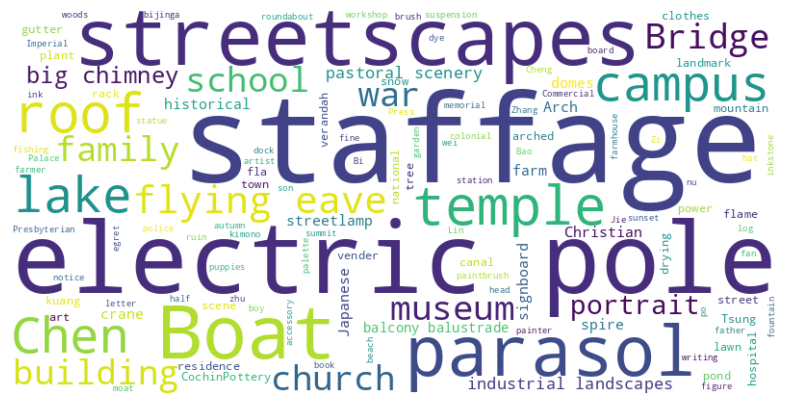

Word frequency in the subjects:
electric: 15
pole,: 15
staffage,: 13
staffage: 10
Boat,: 8
parasol,: 7
streetscapes: 7
temple: 6
roof,: 6
flying: 5
eave,: 5
Chen: 5
big: 4
chimney,: 4
industrial: 4
landscapes,: 4
war: 4
school,: 4
pastoral: 4
farm,: 3
spire,: 3
Arch: 3
Bridge,: 3
historical: 3
crane,: 3
lake,: 3
signboard,: 3
balcony,: 3
balustrade,: 3
Japanese: 3
museum,: 3
streetlamp: 3
Christian: 3
scenery,: 3
family: 3
campus: 3
canal,: 2
clothes: 2
drying: 2
rack,: 2
residence,: 2
lake: 2
CochinPottery,: 2
street: 2
vender,: 2
flame: 2
tree: 2
national: 2
fla,: 2
art: 2
building,: 2
Tsung-kuang,: 2
scene,: 2
power: 2
plant: 2
domes,: 2
portrait,: 2
gutter,: 2
Portraits,: 2
streetscapes,: 2
arched: 2
verandah,: 2
campus,: 2
lawn,: 2
pond,: 2
church: 2
mountain: 2
town,: 2
landmark: 2
building: 2
dye: 1
workshop,: 1
fishing,: 1
suspension: 1
bridges: 1
police: 1
station,: 1
fountain,: 1
roundabout,: 1
fine: 1
notice: 1
board,: 1
colonial: 1
hospital: 1
hospital,: 1
Presbyterian: 1
C

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import re

# Lista di stop words comuni in inglese
stop_words = {"of", "the", "at", "in", "a", "by", "on", "and", "to", "for", "with", "from"}

# Caricare il file CSV
csv_filename = "/content/paintings_info.csv"  # Cambia se necessario
df = pd.read_csv(csv_filename)

# Filtrare solo i soggetti diversi da "None"
df_filtered = df[df['Subjects'] != "None"]

# Unire tutti i soggetti in un unico testo
text = " ".join(df_filtered['Subjects'].dropna())

# Separare le parole e rimuovere le stop words
words = [word for word in text.split() if word.lower() not in stop_words]

# Contare la frequenza delle parole
word_counts = Counter(words)

# Generare la word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(" ".join(words))

# Mostrare la word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Stampare la lista delle parole con il relativo conteggio
print("Word frequency in the subjects:")
for word, count in word_counts.most_common():
    print(f"{word}: {count}")

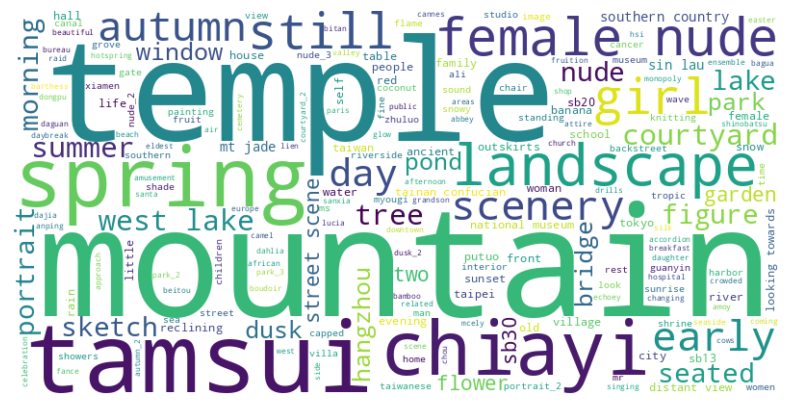

[('mountain', 14),
 ('nude', 14),
 ('temple', 12),
 ('tamsui', 12),
 ('female', 12),
 ('spring', 11),
 ('chiayi', 11),
 ('lake', 11),
 ('landscape', 9),
 ('still', 8),
 ('scenery', 7),
 ('autumn', 7),
 ('west', 7),
 ('early', 7),
 ('girl', 7),
 ('southern', 6),
 ('street', 6),
 ('courtyard', 6),
 ('summer', 6),
 ('day', 5)]

In [ ]:
import pandas as pd
from collections import Counter
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Lista di stop words comuni in inglese
stop_words = {"of", "the", "at", "in", "a", "by", "on"}

# Caricare il file CSV
file_path = "/content/paintings_info.csv"
df = pd.read_csv(file_path)

# Controllare se la colonna "Title" esiste
if "Title" in df.columns:
    # Concatenare tutti i titoli in un unico testo
    all_titles = " ".join(df["Title"].dropna())

    # Rimuovere la punteggiatura e convertire in minuscolo
    words = re.findall(r'\b\w+\b', all_titles.lower())

    # Filtrare le parole rimuovendo le stop words
    filtered_words = [word for word in words if word not in stop_words]

    # Contare le parole
    word_counts = Counter(filtered_words)

    # Ordinare le parole per frequenza decrescente
    most_common_words = word_counts.most_common(20)  # Prendere le prime 20 parole più frequenti

    # Creare e visualizzare la word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(filtered_words))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()
else:
    most_common_words = "Colonna 'Title' non trovata nel file CSV."

most_common_words

The results show a series of recurring keywords in the **titles** and the **subjects** of the paintings, providing insight into the most represented themes.  

- **Recurring themes**: Among the most frequent words, we find landscape elements such as *mountain*, *lake*, *temple*, *scenery*, and *landscape*. This suggests a strong interest in depicting nature and outdoor environments.  
- **Human figures**: Terms like *nude*, *female*, and *girl* indicate the presence of portraits and studies of the human body, with a particular focus on female figures.  
- **Specific locations**: Some geographical names like *Tamsui* and *Chiayi* suggest a connection to Taiwanese settings, confirming a link to the local context.  
- **Seasons and times of the day**: Words like *spring*, *autumn*, *summer*, and *day* may indicate attention to atmospheric and seasonal changes in the paintings.  
- **Other urban and architectural elements**: Terms such as *street*, *courtyard*, and *temple* also suggest an interest in scenes of daily life and traditional architecture.

**Geospatial Analysis of Chen Cheng-po's Paintings**

Then we refocused on Chen Cheng-po, the most prolific artist in the dataset, and asked ourselves in which locations the highest number of his paintings can be found in order to map his artistic production.

In [ ]:
import pandas as pd
import numpy as np
import csv
import logging
from rdflib import Graph, Namespace
from bokeh.plotting import figure, output_notebook, show
from bokeh.models import ColumnDataSource, WMTSTileSource

# Suppress RDFlib warnings
logging.getLogger("rdflib.term").setLevel(logging.ERROR)

# Load the RDF data
g = Graph()
g.parse("/content/ASCDC_Taiwan Artists.owl", format="xml")  # Replace with the actual filename

# Define the namespaces
RDFS = Namespace("http://www.w3.org/2000/01/rdf-schema#")
SCHEMA = Namespace("http://schema.org/")
CRM = Namespace("http://linkedart.ascdc.tw/lod/ontology#")

# Query to retrieve the top content locations for Chen Cheng-po's paintings
query_paintings = """
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX schema: <http://schema.org/>
PREFIX crm: <http://linkedart.ascdc.tw/lod/ontology#>
SELECT ?locationName (COUNT(?painting) AS ?paintingCount)
WHERE {
    ?painting a crm:Painting .
    ?painting schema:creator ?author .
    ?author rdfs:label "Chen Cheng-po"@en .
    ?painting schema:contentLocation ?location .
    ?location rdfs:label ?locationName .
    FILTER (LANG(?locationName) = "en")
}
GROUP BY ?locationName
ORDER BY DESC(?paintingCount)
LIMIT 5
"""

# Execute the query and save results
data_paintings = []
results_paintings = g.query(query_paintings)
for row in results_paintings:
    data_paintings.append([row.locationName, int(row.paintingCount)])

paintings_df = pd.DataFrame(data_paintings, columns=["Content Location", "Number of Paintings"])

# Query to retrieve place information
query_places = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX schema: <http://schema.org/>
PREFIX ex: <http://linkedart.ascdc.tw/lod/ontology#>

SELECT ?place ?label ?latitude ?longitude ?country
WHERE {
    ?place rdf:type ?country .
    ?place rdfs:label ?label .
    ?place schema:latitude ?latitude .
    ?place schema:longitude ?longitude .
    FILTER(?country IN (ex:Taiwan, ex:China, ex:Italy, ex:Japan, ex:France))
    FILTER(LANG(?label) = "en")
}
ORDER BY ?country ?label
"""

# Execute the query and save results
data_places = []
results_places = g.query(query_places)
for row in results_places:
    data_places.append([row.label, row.country.split("#")[-1], float(row.latitude), float(row.longitude)])

places_df = pd.DataFrame(data_places, columns=["Place", "Country", "Latitude", "Longitude"])

# Merge the datasets on location name
merged_df = pd.merge(paintings_df, places_df, left_on="Content Location", right_on="Place")

# Convert lat/lon to Web Mercator
def latlon_to_web_mercator(lat, lon):
    k = 6378137  # Earth radius in meters
    x = float(lon) * (k * np.pi / 180.0)
    y = np.log(np.tan((90 + float(lat)) * np.pi / 360.0)) * k
    return x, y

merged_df["x"], merged_df["y"] = zip(*merged_df.apply(lambda row: latlon_to_web_mercator(row["Latitude"], row["Longitude"]), axis=1))

# Create a size column for scatter plot
merged_df["size"] = merged_df["Number of Paintings"] / merged_df["Number of Paintings"].max() * 20 + 5

# Create the map
output_notebook()
p = figure(x_range=(merged_df["x"].min() - 1e6, merged_df["x"].max() + 1e6),
           y_range=(merged_df["y"].min() - 1e6, merged_df["y"].max() + 1e6),
           x_axis_type="mercator", y_axis_type="mercator",
           title="Map of Chen Cheng-po's paintings")

tile_source = WMTSTileSource(url="https://cartodb-basemaps-a.global.ssl.fastly.net/light_all/{Z}/{X}/{Y}@2x.png")
p.add_tile(tile_source)

source = ColumnDataSource(merged_df)
p.scatter(x="x", y="y", size="size", fill_color="blue", fill_alpha=0.6, line_color="black", source=source)

show(p)


These results indicate that **Jiayi (Chiayi)** holds the highest number of paintings (21) by **Chen Cheng-po**, which is not surprising given that he was born and had a strong connection to the city. His works often depicted scenes from his hometown, reflecting its landscapes and daily life.  

**Hangzhou (9 paintings)** follows as the second most frequent location. This suggests a significant period of influence or artistic production in Hangzhou, possibly during his studies or travels in China.  

**Tamsui (8 paintings)**, a historically and culturally rich area in northern Taiwan, appears next. Its scenic waterfront and colonial architecture may have inspired multiple works.  

**Tainan (4 paintings)** and **Taipei (3 paintings)** show a lower presence, but their inclusion highlights that Chen Cheng-po also explored and painted in other important Taiwanese cities.  

Overall, these numbers suggest a strong personal and artistic link to Jiayi, while also reflecting his broader engagement with different cultural and artistic environments.